In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("/content/Mall_Customers.csv")
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Genre'] = le.fit_transform(data['Genre'])

In [12]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [13]:
x = data[["Annual Income (k$)","Spending Score (1-100)"]]

In [14]:
scalar = StandardScaler()
scalar.fit(x)

StandardScaler()

In [24]:
wcss = []
for i in range(1,9):
  model = KMeans(n_clusters=i,
                 random_state=42)
  model.fit(x)
  wcss.append(model.inertia_)
print(wcss)

[269981.28000000014, 183653.3289473683, 106348.37306211119, 73880.64496247198, 44448.45544793369, 40825.16946386947, 33642.57922077922, 26686.837785187785]


In [30]:
model = KMeans(n_clusters=9,random_state=42)
model.fit(x)


KMeans(n_clusters=9, random_state=42)

In [31]:
data["Clusters"] = model.labels_
print("Cluster Centers")
print(model.cluster_centers_)
print()
print(data.head())

Cluster Centers
[[ 56.46478873  49.77464789]
 [108.18181818  82.72727273]
 [ 79.          16.59259259]
 [ 23.42857143  84.78571429]
 [ 24.58333333   9.58333333]
 [ 78.03571429  81.89285714]
 [ 31.53333333  35.86666667]
 [109.7         22.        ]
 [ 33.5         66.25      ]]

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Clusters
0           1      1   19                  15                      39         6
1           2      1   21                  15                      81         3
2           3      0   20                  16                       6         4
3           4      0   23                  16                      77         3
4           5      0   31                  17                      40         6


In [33]:
for i in range(9):
    print(f"\nCluster {i}")
    print(data[data["Clusters"] == i])


Cluster 0
     CustomerID  Genre  ...  Spending Score (1-100)  Clusters
50           51      0  ...                      52         0
52           53      0  ...                      54         0
54           55      0  ...                      45         0
56           57      0  ...                      50         0
57           58      1  ...                      46         0
..          ...    ...  ...                     ...       ...
119         120      0  ...                      57         0
120         121      1  ...                      56         0
121         122      0  ...                      40         0
122         123      0  ...                      58         0
142         143      0  ...                      40         0

[71 rows x 6 columns]

Cluster 1
     CustomerID  Genre  ...  Spending Score (1-100)  Clusters
179         180      1  ...                      90         1
181         182      0  ...                      86         1
183         184      0  .

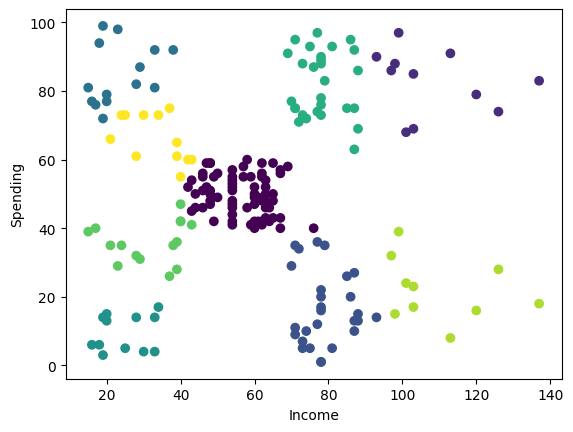

In [34]:
import matplotlib.pyplot as plt

plt.scatter(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"],
    c=data["Clusters"]
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()